In [2]:
import numpy as np

# Hours studied
X = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0,
              5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0])

# 1 = passed, 0 = failed (noisy boundary around 3-6 hours)
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
              1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [3]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [4]:
def binary_cross_entropy_loss(y_true, y_pred):
    return -np.mean((y_true * np.log(y_pred)) + ((1-y_true) * np.log(1-y_pred)))

In [5]:
# Inatilizing variable
w=0.0
b=0.0

# Hyperparameters
learning_rate = 0.1
epochs = 10000
n = len(X)

for epoch in range(epochs):
    z = w * X + b
    y_pred = sigmoid(z)
    error = y_pred - y

    # calculate gradients
    dw = (1/n) * np.sum(error * X)
    db = (1/n) * np.sum(error)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 1000 == 0:
        loss = binary_cross_entropy_loss(y, y_pred)
        print(f"Epoch: {epoch}, w = {w:.4f}, b = {b:.4f}, loss = {loss:.4f}")
print(f"Final w = {w:.4f}, b = {b:.4f}")

Epoch: 0, w = 0.1375, b = 0.0050, loss = 0.6931
Epoch: 1000, w = 0.9037, b = -4.1660, loss = 0.2922
Epoch: 2000, w = 1.0429, b = -4.9041, loss = 0.2859
Epoch: 3000, w = 1.0946, b = -5.1758, loss = 0.2851
Epoch: 4000, w = 1.1164, b = -5.2902, loss = 0.2850
Epoch: 5000, w = 1.1261, b = -5.3408, loss = 0.2849
Epoch: 6000, w = 1.1304, b = -5.3636, loss = 0.2849
Epoch: 7000, w = 1.1324, b = -5.3739, loss = 0.2849
Epoch: 8000, w = 1.1333, b = -5.3787, loss = 0.2849
Epoch: 9000, w = 1.1337, b = -5.3808, loss = 0.2849
Final w = 1.1339, b = -5.3818


In [6]:
# Predictions
print("\n--- Predictions ---")
test_hours = [2, 4.5, 7, 9]
for h in test_hours:
    prob = sigmoid(w * h + b)
    pred = 1 if prob > 0.5 else 0
    label = "PASS" if pred == 1 else "FAIL"
    print(f"Studied {h} hrs → P(pass) = {prob:.4f} → Predicted: {label}")


--- Predictions ---
Studied 2 hrs → P(pass) = 0.0425 → Predicted: FAIL
Studied 4.5 hrs → P(pass) = 0.4306 → Predicted: FAIL
Studied 7 hrs → P(pass) = 0.9279 → Predicted: PASS
Studied 9 hrs → P(pass) = 0.9920 → Predicted: PASS


In [7]:
# Accuarcy
train_prob = sigmoid(w * X + b)
train_pred = (train_prob > 0.5).astype(int)
accuracy = np.mean(train_pred == y)
print(f"\nTraining accuracy: {accuracy*100:.2f}%")


Training accuracy: 90.00%


In [8]:
# Confusion matrix breakdown
TP = np.sum((train_pred==1) & (y==1))
TN = np.sum((train_pred==0) & (y==0))
FP = np.sum((train_pred==1) & (y==0))
FN = np.sum((train_pred==0) & (y==1))

print(f"\n--- Confusion Matrix ---")
print(f"True Positives (correctly predicted pass): {TP}")
print(f"True Negatives (correctly predicted fail): {TN}")
print(f"False Positives (predicted pass, actually failed): {FP}")
print(f"False Negatives (predicted fail, actually passed): {FN}")


--- Confusion Matrix ---
True Positives (correctly predicted pass): 10
True Negatives (correctly predicted fail): 8
False Positives (predicted pass, actually failed): 1
False Negatives (predicted fail, actually passed): 1


In [9]:
# Decision boundary
decision_boundary = -b/w
print(f"\nDecision boundary: {decision_boundary:.2f} hours")


Decision boundary: 4.75 hours


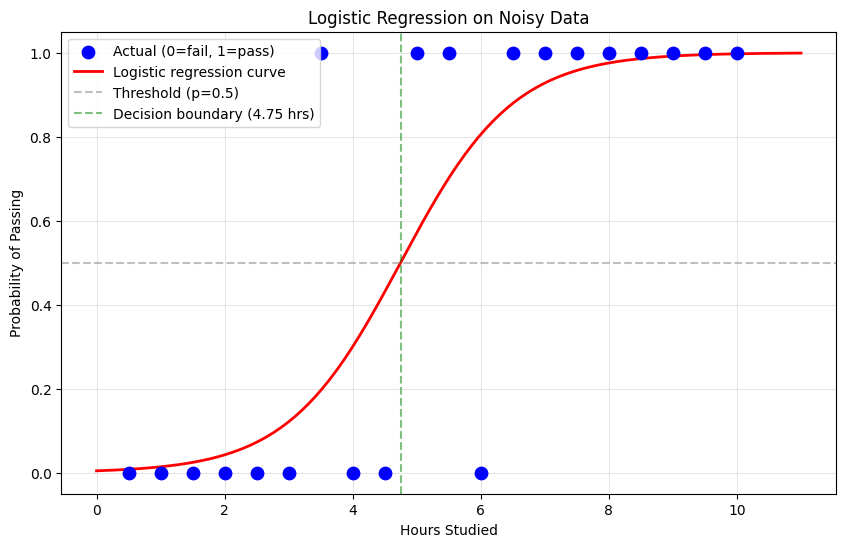

In [10]:
# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', s=80, label='Actual (0=fail, 1=pass)', zorder=3)

X_smooth = np.linspace(0, 11, 200)
y_smooth = sigmoid(w * X_smooth + b)
plt.plot(X_smooth, y_smooth, color='red', linewidth=2, label='Logistic regression curve')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold (p=0.5)')
plt.axvline(x=decision_boundary, color='green', linestyle='--', alpha=0.5,
            label=f'Decision boundary ({decision_boundary:.2f} hrs)')

plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression on Noisy Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ROC => reciever Operator Characterstics
import random
TPR = []
FPR = []
def compute_roc(thresold):
    # print(f"\n--- Selected Thresold ---")
    # print(thresold)
    # train_prob = sigmoid(w * X + b)
    train_pred = (train_prob > thresold).astype(int)
    TP = np.sum((train_pred==1) & (y==1))
    TN = np.sum((train_pred==0) & (y==0))
    FP = np.sum((train_pred==1) & (y==0))
    FN = np.sum((train_pred==0) & (y==1))
    
    # print(f"\n--- Confusion Matrix ---")
    # print(f"True Positives (correctly predicted pass): {TP}")
    # print(f"True Negatives (correctly predicted fail): {TN}")
    # print(f"False Positives (predicted pass, actually failed): {FP}")
    # print(f"False Negatives (predicted fail, actually passed): {FN}")

    true_positive_rate = TP/(TP+FN)
    false_positive_rate = FP/(FP+TN)
    TPR.append(true_positive_rate)
    FPR.append(false_positive_rate)
    
    # print(f"\n--- ROC ---")
    # print(f"True Positive Rate: {true_positive_rate:.2f}")
    # print(f"False Positive Rate: {false_positive_rate:.2f}")

In [12]:
thresolds = [0.1, 0.3, 0.4, 0.5, 0.7, 0.8, 0.9, 0.99]
for thresold in thresolds:
    compute_roc(thresold)

FPR.sort()
TPR.sort()

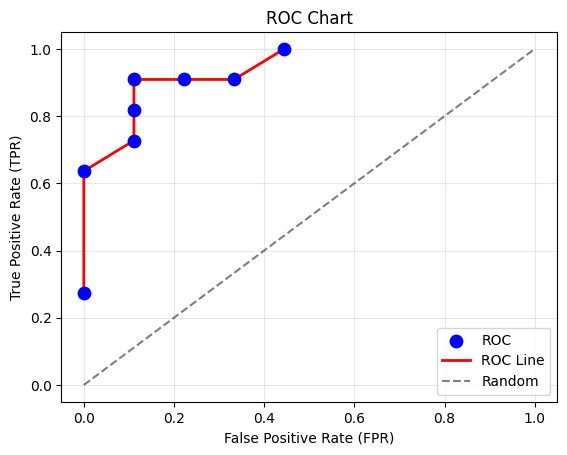

In [13]:
# Visualize
import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
plt.scatter(FPR, TPR, color='blue', s=80, label='ROC', zorder=3)

plt.plot(FPR, TPR, color='red', linewidth=2, label='ROC Line')
# plt.plot([min(FPR), max(FPR)], [min(TPR), max(TPR)], 'k--', alpha=0.5, label='Random classifier')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.title('ROC Chart')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y, train_prob)
print(f"AUC: {auc:.4f}")

AUC: 0.9495


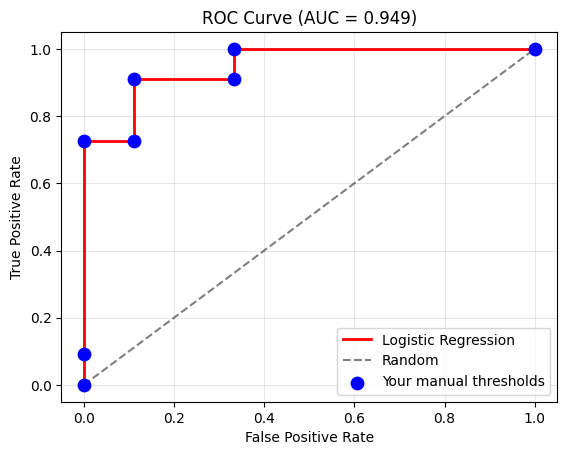

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y, train_prob)

plt.plot(fpr, tpr, color='red', linewidth=2, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.scatter(fpr, tpr, color='blue', s=80, label='Your manual thresholds', zorder=3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()